# Previous version


## Мобильное приложение
На мобильном устройстве пользователя в файл пишутся действия пользователя и системы в процессе взаимодействия с устройством.

Действия записываются без метки "полезная деятельность/бесполезная". Фильтр по типу деятельности приходится выполнять в ручном режиме - запускать службу и следить, чтобы во время её работы выполнялся только один тип деятельности.

Записываются не все параметры, которые собирает система, а только некоторые, предположительно информативные.

## Нейронная часть
Реализация отсутствует. Есть предположение по подходящим алгоритмам

# New Version


## Мобильное приложение
Действия размечаются по типу деятельности:
*   полезная деятельность
*   короткие видео
*   бесполезная(не только короткие видео)
*   неопределенное(если метку не проставил пользователь)

Улучшен интерфейс. Теперь можно более гибко управляться с записью своих действий в файл.

### Диалог с выбором типа деятельности



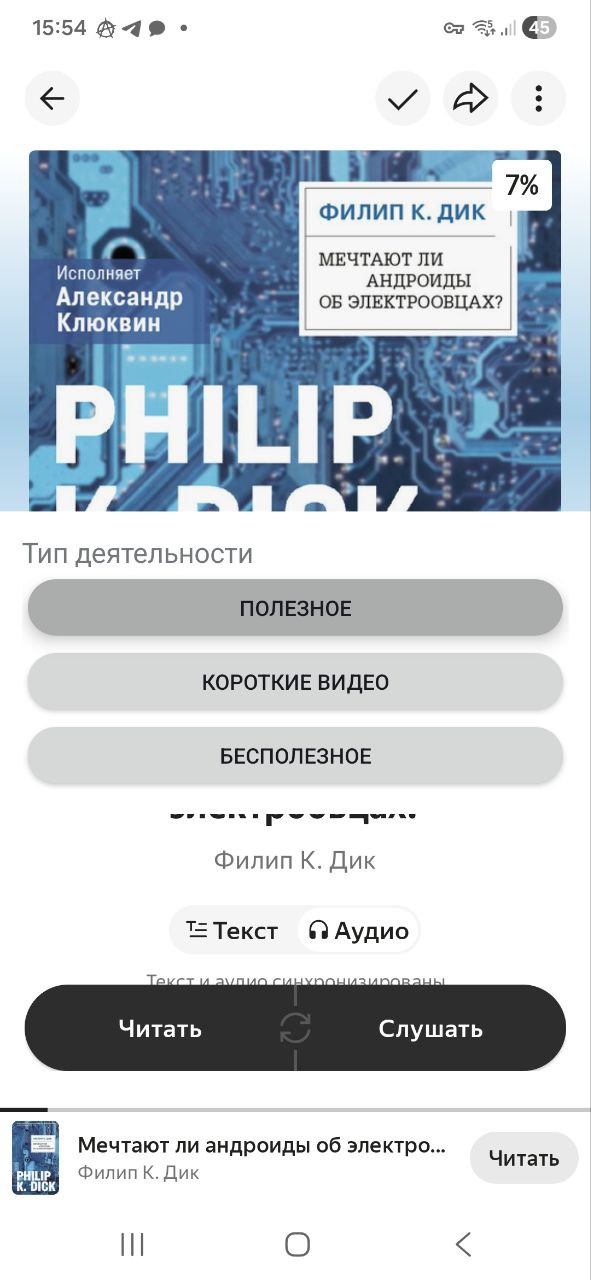

### Интерфейс приложения

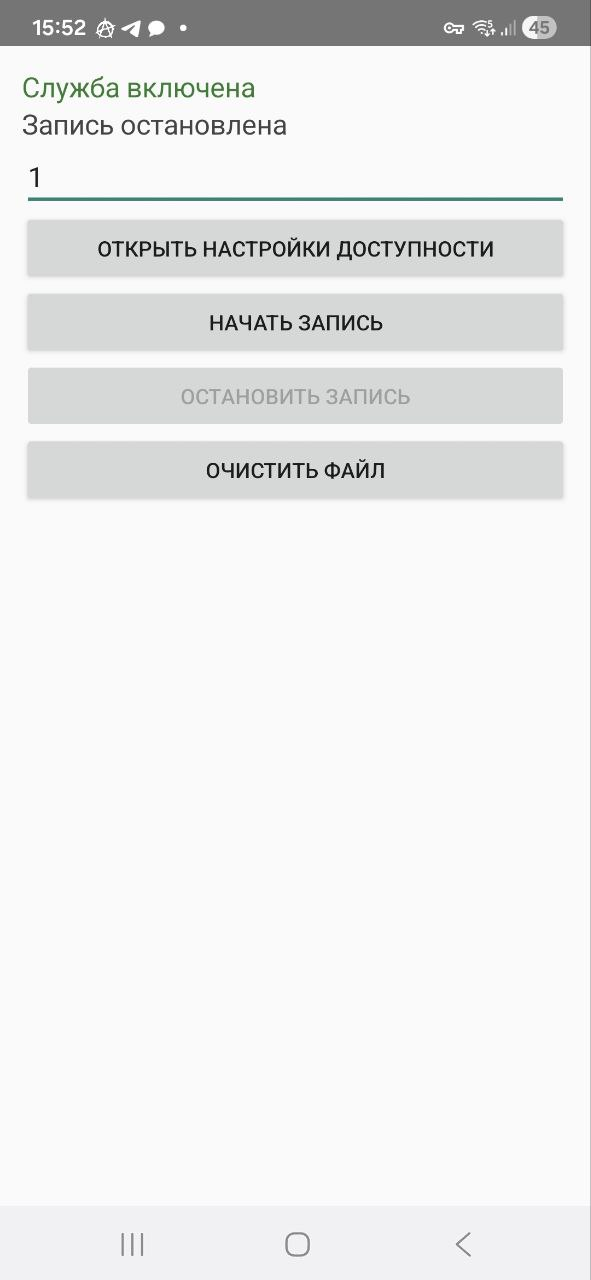

## Искуственно-интеллектуальная часть
Показана ниже

Предполагается, что на вход серверному приложению подаётся файл с действиями пользователя. На его основе выделятся признак, по которым можно охарактеризовать тип деятеьноти и по которым учится алгоритм.

Ниже показан процесс выделения этих признаком, их описание, характеризующие датасет графики и три попытки обучения разных моделей

In [49]:
import pandas as pd
from google.colab import drive

drive.mount('/content/drive', force_remount=True)
data = pd.read_csv('/content/drive/My Drive/Colab Notebooks/Диплом/data_1512.csv')

Mounted at /content/drive


In [72]:
df = data

In [25]:
#appenddata = pd.read_csv('/content/drive/My Drive/Colab Notebooks/Диплом/tiktokActivity.csv')
#df = pd.concat([appenddata, data], ignore_index=True)

In [48]:
import numpy as np
import matplotlib.pyplot as plt
import gdown
from pathlib import Path

RAW_FILE = data
PROCESSED_FILE = "gesture_features.csv"

CHECK_INTERVAL_MIN = 2  # в минутах

In [73]:
df.head(5)

,sessionId,activityType,eventType,eventTime,package
0,2e429fcc-940c-4903-ae65-469e3793c933,tiktok,tiktok,96791741,2e429fcc-940c-4903-ae65-469e3793c933
1,2e429fcc-940c-4903-ae65-469e3793c933,tiktok,tiktok,96791747,2e429fcc-940c-4903-ae65-469e3793c933
2,2e429fcc-940c-4903-ae65-469e3793c933,tiktok,tiktok,96791782,2e429fcc-940c-4903-ae65-469e3793c933
3,2e429fcc-940c-4903-ae65-469e3793c933,tiktok,tiktok,96791782,2e429fcc-940c-4903-ae65-469e3793c933
4,2e429fcc-940c-4903-ae65-469e3793c933,tiktok,tiktok,96791858,2e429fcc-940c-4903-ae65-469e3793c933


In [74]:
df.tail(5)

,sessionId,activityType,eventType,eventTime,package
94113,5106715c-7555-4ae8-8acd-984d14bf0a3f,tiktok,TYPE_WINDOW_CONTENT_CHANGED,377876833,com.android.systemui
94114,5106715c-7555-4ae8-8acd-984d14bf0a3f,tiktok,TYPE_WINDOW_CONTENT_CHANGED,377876933,com.android.systemui
94115,5106715c-7555-4ae8-8acd-984d14bf0a3f,tiktok,TYPE_WINDOW_CONTENT_CHANGED,377877033,com.android.systemui
94116,5106715c-7555-4ae8-8acd-984d14bf0a3f,tiktok,TYPE_WINDOW_CONTENT_CHANGED,377877133,com.android.systemui
94117,5106715c-7555-4ae8-8acd-984d14bf0a3f,tiktok,TYPE_WINDOW_CONTENT_CHANGED,377877233,com.android.systemui


In [75]:
# eventTime в милисекундах
df["eventTime"] = pd.to_numeric(df["eventTime"], errors="coerce")
df = df.dropna(subset=["eventTime"])

# преобразование в datetime
# время будет в 1970, но дальше мы будем считать разницу между событиями, а время вроде не стало идти быстрее с 1970 года
df["timestamp"] = pd.to_datetime(df["eventTime"], unit="ms")

# преобразование в строки
df["eventType"] = df["eventType"].astype(str)
df["package"] = df["package"].astype(str)
df["activityType"] = df["activityType"].astype(str)

In [76]:
df.head(10)

,sessionId,activityType,eventType,eventTime,package,timestamp
0,2e429fcc-940c-4903-ae65-469e3793c933,tiktok,tiktok,96791741,2e429fcc-940c-4903-ae65-469e3793c933,1970-01-02 02:53:11.741
1,2e429fcc-940c-4903-ae65-469e3793c933,tiktok,tiktok,96791747,2e429fcc-940c-4903-ae65-469e3793c933,1970-01-02 02:53:11.747
2,2e429fcc-940c-4903-ae65-469e3793c933,tiktok,tiktok,96791782,2e429fcc-940c-4903-ae65-469e3793c933,1970-01-02 02:53:11.782
3,2e429fcc-940c-4903-ae65-469e3793c933,tiktok,tiktok,96791782,2e429fcc-940c-4903-ae65-469e3793c933,1970-01-02 02:53:11.782
4,2e429fcc-940c-4903-ae65-469e3793c933,tiktok,tiktok,96791858,2e429fcc-940c-4903-ae65-469e3793c933,1970-01-02 02:53:11.858
5,2e429fcc-940c-4903-ae65-469e3793c933,tiktok,tiktok,96791901,2e429fcc-940c-4903-ae65-469e3793c933,1970-01-02 02:53:11.901
6,2e429fcc-940c-4903-ae65-469e3793c933,tiktok,tiktok,96791944,2e429fcc-940c-4903-ae65-469e3793c933,1970-01-02 02:53:11.944
7,2e429fcc-940c-4903-ae65-469e3793c933,tiktok,tiktok,96791944,2e429fcc-940c-4903-ae65-469e3793c933,1970-01-02 02:53:11.944
8,2e429fcc-940c-4903-ae65-469e3793c933,tiktok,tiktok,96792046,2e429fcc-940c-4903-ae65-469e3793c933,1970-01-02 02:53:12.046
9,2e429fcc-940c-4903-ae65-469e3793c933,tiktok,tiktok,96792153,2e429fcc-940c-4903-ae65-469e3793c933,1970-01-02 02:53:12.153


Наши любимые окна
Нарезаем сессии на 2минутные отрезки

In [77]:
df["windowStart"] = df["timestamp"].dt.floor(f"{CHECK_INTERVAL_MIN}min")

In [79]:
grouped = df.groupby(["sessionId", "windowStart", "activityType"],dropna=False)


Для событий добавлено время начала сессии (windowStart)

In [80]:
sessions = df["sessionId"].unique()

s1, s2, s3 = sessions[:3]

sample_df = pd.concat([
    df[df["sessionId"] == s1].head(5),
    df[df["sessionId"] == s2].head(5),
    df[df["sessionId"] == s3].head(5)
])

sample_df

,sessionId,activityType,eventType,eventTime,package,timestamp,windowStart
0,2e429fcc-940c-4903-ae65-469e3793c933,tiktok,tiktok,96791741,2e429fcc-940c-4903-ae65-469e3793c933,1970-01-02 02:53:11.741,1970-01-02 02:50:00
1,2e429fcc-940c-4903-ae65-469e3793c933,tiktok,tiktok,96791747,2e429fcc-940c-4903-ae65-469e3793c933,1970-01-02 02:53:11.747,1970-01-02 02:50:00
2,2e429fcc-940c-4903-ae65-469e3793c933,tiktok,tiktok,96791782,2e429fcc-940c-4903-ae65-469e3793c933,1970-01-02 02:53:11.782,1970-01-02 02:50:00
3,2e429fcc-940c-4903-ae65-469e3793c933,tiktok,tiktok,96791782,2e429fcc-940c-4903-ae65-469e3793c933,1970-01-02 02:53:11.782,1970-01-02 02:50:00
4,2e429fcc-940c-4903-ae65-469e3793c933,tiktok,tiktok,96791858,2e429fcc-940c-4903-ae65-469e3793c933,1970-01-02 02:53:11.858,1970-01-02 02:50:00
61876,84f63478-01e8-4015-a5b0-7cd1ef6f2874,doom,TYPE_WINDOW_CONTENT_CHANGED,357020125,com.example.antitiktok,1970-01-05 03:10:20.125,1970-01-05 03:10:00
61877,84f63478-01e8-4015-a5b0-7cd1ef6f2874,doom,TYPE_WINDOW_CONTENT_CHANGED,357020126,com.example.antitiktok,1970-01-05 03:10:20.126,1970-01-05 03:10:00
61878,84f63478-01e8-4015-a5b0-7cd1ef6f2874,doom,TYPE_VIEW_CLICKED,357020126,com.example.antitiktok,1970-01-05 03:10:20.126,1970-01-05 03:10:00
61879,84f63478-01e8-4015-a5b0-7cd1ef6f2874,doom,TYPE_WINDOW_CONTENT_CHANGED,357021766,com.sec.android.app.launcher,1970-01-05 03:10:21.766,1970-01-05 03:10:00
61880,84f63478-01e8-4015-a5b0-7cd1ef6f2874,doom,TYPE_WINDOW_STATE_CHANGED,357021767,com.sec.android.app.launcher,1970-01-05 03:10:21.767,1970-01-05 03:10:00


Типы данных в наборе:

In [81]:
types = df["activityType"].unique()
types

array(['tiktok', 'doom', 'unknown', 'good'], dtype=object)

Для данного набора данных известно, что unknown = good, заменим. На будущее будем удалять

In [60]:
#df["activityType"] = df["activityType"].replace("unknown", "good")
#types = df["activityType"].unique()
#types

array(['doom', 'tiktok', 'good'], dtype=object)

In [82]:
features = grouped.apply(lambda g: pd.Series({

    # -------- базовые счётчики --------
    "event_count": len(g),

    "scroll_count": (g["eventType"] == "TYPE_VIEW_SCROLLED").sum(),
    "click_count": (g["eventType"] == "TYPE_VIEW_CLICKED").sum(),

    # -------- интенсивность --------
    "scrolls_per_minute":
        (g["eventType"] == "TYPE_VIEW_SCROLLED").sum() / CHECK_INTERVAL_MIN,

    # -------- приложения --------
    "unique_apps": g["package"].nunique(),

    "top_app_ratio":
        g["package"].value_counts(normalize=True).iloc[0]
        if len(g) > 0 else 0,

    # -------- темп событий --------
    "mean_inter_event_time_ms":
        g["timestamp"].diff().dt.total_seconds().mean() * 1000
        if len(g) > 1 else 0,

}))


/tmp/ipython-input-3468292954.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  features = grouped.apply(lambda g: pd.Series({


In [83]:
features_df = features.reset_index()

# Убираем NaN / inf
features_df = (
    features_df
    .replace([np.inf, -np.inf], 0)
    .fillna(0)
)


In [90]:
features_df.head(5)


,sessionId,windowStart,event_count,scroll_count,click_count,scrolls_per_minute,unique_apps,top_app_ratio,mean_inter_event_time_ms,activityType
0,0c935730-f4fa-48ee-889b-df26621b8e96,1970-01-05 03:15:00,2239.0,16.0,1.0,3.2,2.0,0.998213,115.626452,tiktok
1,0c935730-f4fa-48ee-889b-df26621b8e96,1970-01-05 03:20:00,3638.0,549.0,6.0,109.8,2.0,0.998626,82.477866,tiktok
2,0c935730-f4fa-48ee-889b-df26621b8e96,1970-01-05 03:25:00,366.0,2.0,2.0,0.4,5.0,0.945355,113.252055,tiktok
3,0c935730-f4fa-48ee-889b-df26621b8e96,1970-01-05 04:15:00,288.0,20.0,8.0,4.0,10.0,0.371528,845.902439,good
4,0c935730-f4fa-48ee-889b-df26621b8e96,1970-01-05 04:20:00,371.0,0.0,0.0,0.0,4.0,0.991914,693.548649,good


Переместим в конец столбец с целевой переменной

In [91]:
cols = [c for c in features_df.columns if c != "activityType"] + ["activityType"]
features_df = features_df[cols]
features_df.head(5)

,sessionId,windowStart,event_count,scroll_count,click_count,scrolls_per_minute,unique_apps,top_app_ratio,mean_inter_event_time_ms,activityType
0,0c935730-f4fa-48ee-889b-df26621b8e96,1970-01-05 03:15:00,2239.0,16.0,1.0,3.2,2.0,0.998213,115.626452,tiktok
1,0c935730-f4fa-48ee-889b-df26621b8e96,1970-01-05 03:20:00,3638.0,549.0,6.0,109.8,2.0,0.998626,82.477866,tiktok
2,0c935730-f4fa-48ee-889b-df26621b8e96,1970-01-05 03:25:00,366.0,2.0,2.0,0.4,5.0,0.945355,113.252055,tiktok
3,0c935730-f4fa-48ee-889b-df26621b8e96,1970-01-05 04:15:00,288.0,20.0,8.0,4.0,10.0,0.371528,845.902439,good
4,0c935730-f4fa-48ee-889b-df26621b8e96,1970-01-05 04:20:00,371.0,0.0,0.0,0.0,4.0,0.991914,693.548649,good


##Признаки
**sessionId**	- GUID сессии. Используется для объединения событий в одну пользовательскую сессию

**windowStart**	- Начало сессии или окна

**activityType**	- Тип активности или приложения

**event_count**	- Общее количество событий, зафиксированных в рамках окна

**scroll_count** - Количество событий скролла в рамках окна

**click_count**	 - Количество кликов или взаимодействий с элементами интерфейса

**scrolls_per_minute**	- Среднее количество прокруток в минуту

**unique_apps**	- Количество уникальных приложений, зафиксированных в рамках окна

**top_app_ratio** -	Доля наиболее часто используемого приложения относительно всех событий в рамках окна

**mean_inter_event_time_ms** - Среднее время между последовательными событиями в миллисекундах

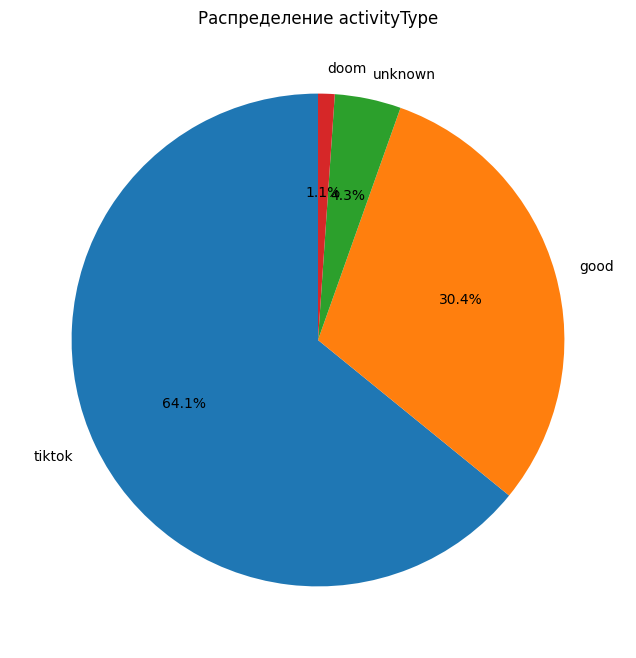

In [101]:
types_counts = features_df['activityType'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(
    types_counts.values,
    labels=types_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Распределение activityType')
plt.show()

In [114]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

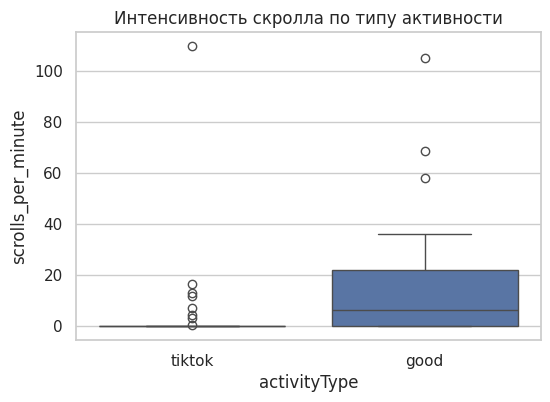

In [116]:
plt.figure(figsize=(6,4))
sns.boxplot(
    data=features_df,
    x="activityType",
    y="scrolls_per_minute"
)
plt.title("Интенсивность скролла по типу активности")
plt.show()


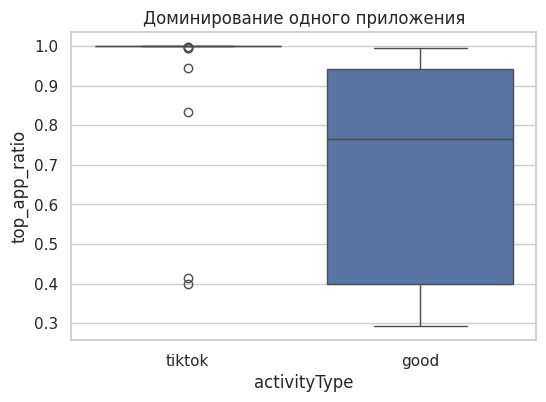

In [117]:
plt.figure(figsize=(6,4))
sns.boxplot(
    data=features_df,
    x="activityType",
    y="top_app_ratio"
)
plt.title("Доминирование одного приложения")
plt.show()


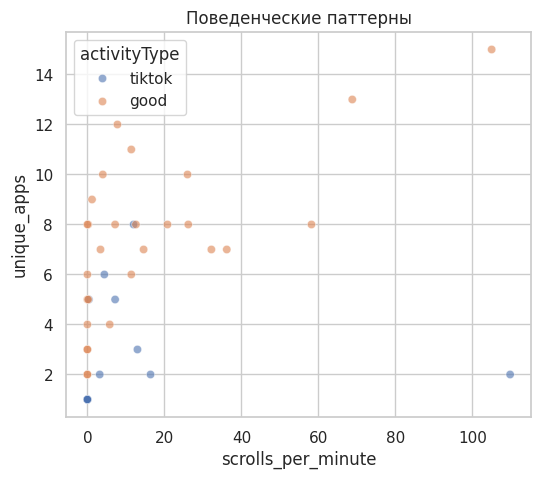

In [118]:
plt.figure(figsize=(6,5))
sns.scatterplot(
    data=features_df,
    x="scrolls_per_minute",
    y="unique_apps",
    hue="activityType",
    alpha=0.6
)
plt.title("Поведенческие паттерны")
plt.show()


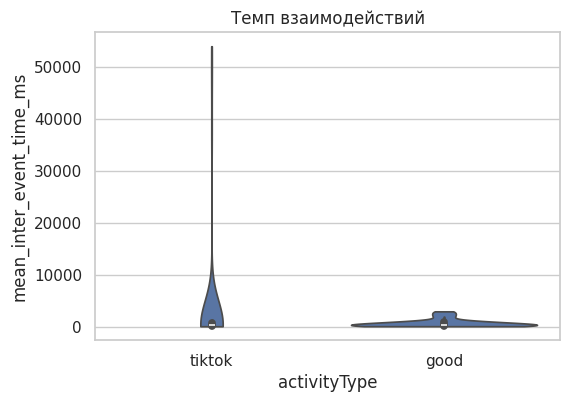

In [119]:
plt.figure(figsize=(6,4))
sns.violinplot(
    data=features_df,
    x="activityType",
    y="mean_inter_event_time_ms",
    cut=0
)
plt.title("Темп взаимодействий")
plt.show()


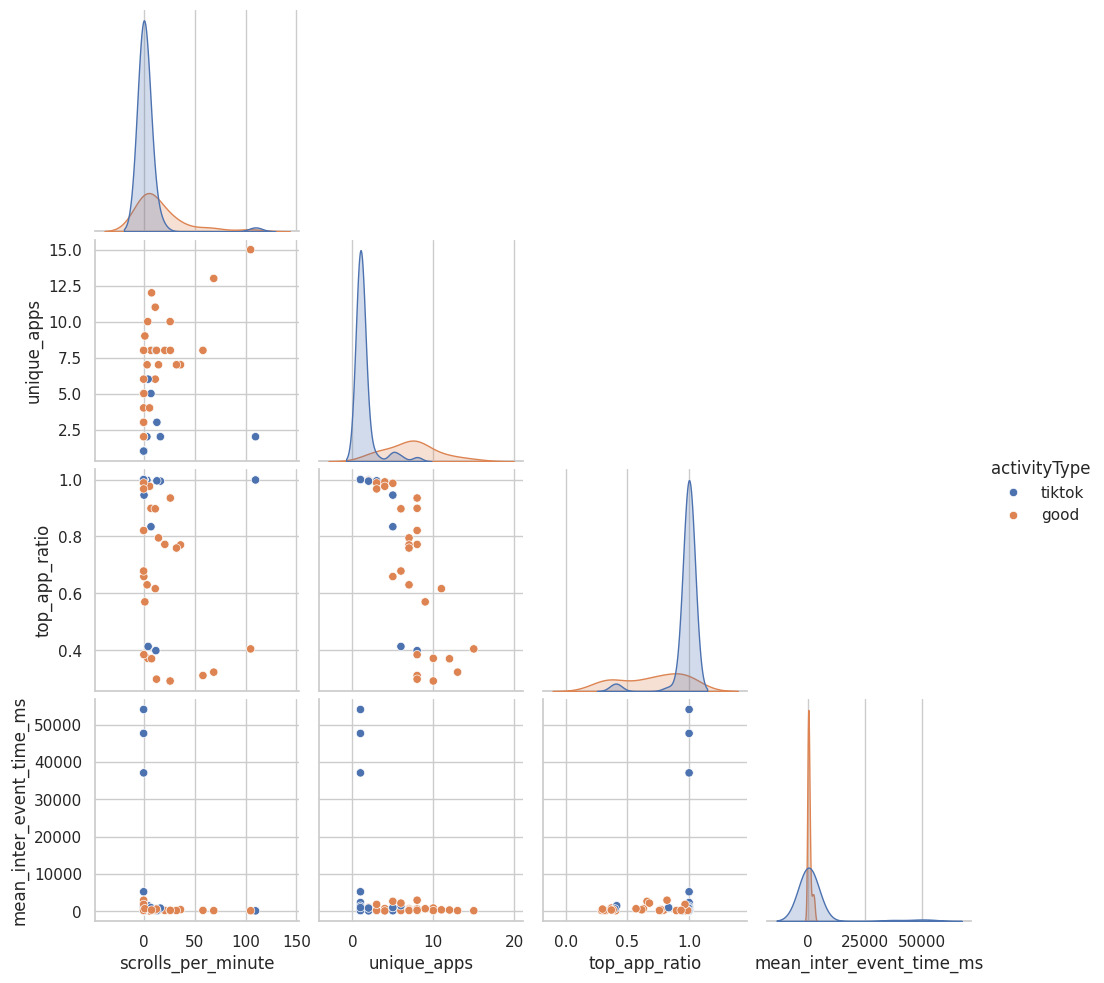

In [120]:
sns.pairplot(
    features_df,
    vars=[
        "scrolls_per_minute",
        "unique_apps",
        "top_app_ratio",
        "mean_inter_event_time_ms"
    ],
    hue="activityType",
    corner=True
)
plt.show()


### Интересные выводы по графикам
Классы не линейно разделимы, но заметны поведенческие паттерны.
Короткие видео отличаются высокой частотой прокруток, низким числом используемых приложений и преобаладанием одного приложения.
В то же время полезная активность характеризуется большей вариативностью приложений и большими интервалами между событиями.

## Подготовка данных

Добавим данных класса good, удалим малочисленные doom и unknown

In [103]:
features_df = features_df[~features_df['activityType'].isin(['unknown', 'doom'])]

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import SMOTENC

X = features_df.drop(columns=['activityType', 'sessionId', 'windowStart'])
y = features_df['activityType']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

# кодирование категориального столбца
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

smote = SMOTE(
    sampling_strategy='not majority',
    random_state=42,
    k_neighbors=5
)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train_enc)

In [104]:
X.head(5)

,event_count,scroll_count,click_count,scrolls_per_minute,unique_apps,top_app_ratio,mean_inter_event_time_ms
0,2239.0,16.0,1.0,3.2,2.0,0.998213,115.626452
1,3638.0,549.0,6.0,109.8,2.0,0.998626,82.477866
2,366.0,2.0,2.0,0.4,5.0,0.945355,113.252055
3,288.0,20.0,8.0,4.0,10.0,0.371528,845.902439
4,371.0,0.0,0.0,0.0,4.0,0.991914,693.548649


In [106]:
dict(zip(le.classes_, le.transform(le.classes_)))

{'good': np.int64(0), 'tiktok': np.int64(1)}

0 - полезное
1 - тиктоки

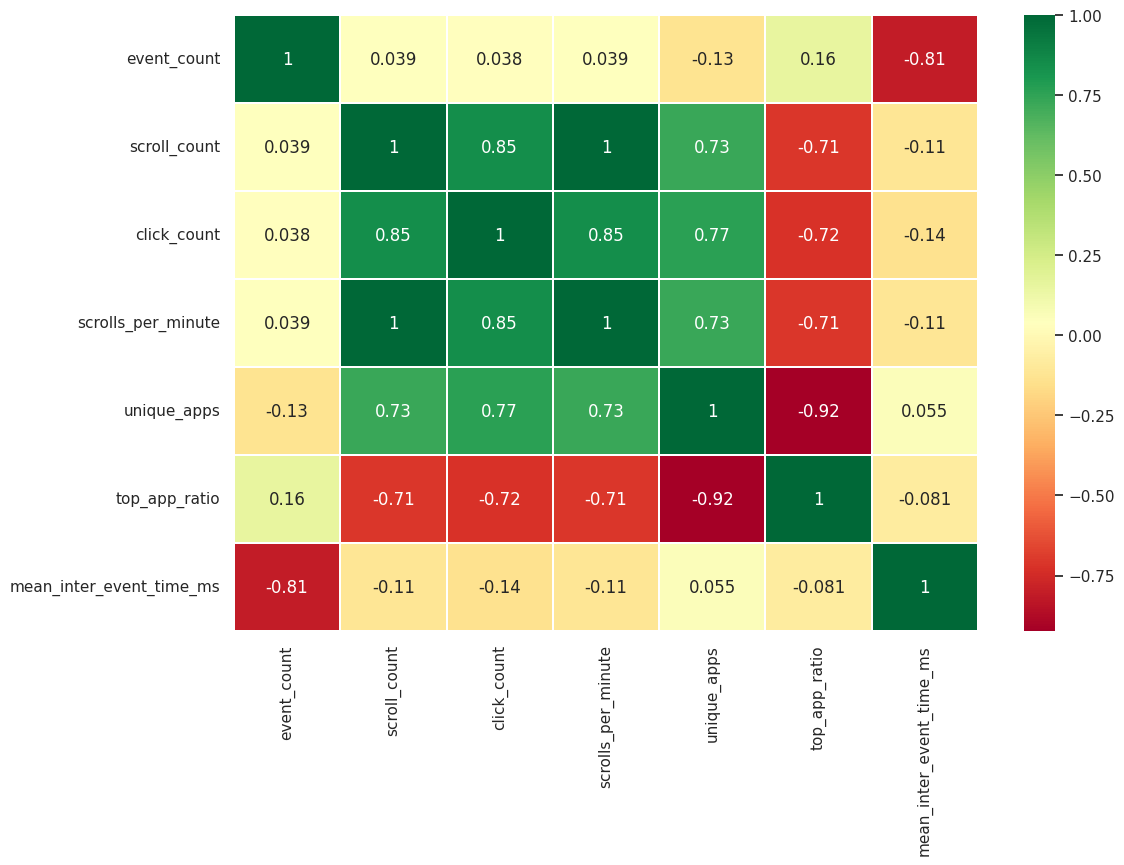

In [132]:
sns.heatmap(X.corr('kendall'),annot=True,cmap='RdYlGn',linewidths=0.2)
fig=plt.gcf()
fig.set_size_inches(12, 8)
plt.show()

Отрицательная корреляция между числом уникальных приложений и долей доминирующего приложения подтверждает гипотезу о различиях между полезной деятельностью и потреблением коротких видео.

## Обучение

### Попытка обучить случайный лес

In [121]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train_res, y_train_res)

y_pred = rf.predict(X_test)

print(classification_report(
    y_test_enc,
    y_pred,
    target_names=le.classes_
))

              precision    recall  f1-score   support

        good       0.78      1.00      0.88         7
      tiktok       1.00      0.87      0.93        15

    accuracy                           0.91        22
   macro avg       0.89      0.93      0.90        22
weighted avg       0.93      0.91      0.91        22



Тиктоки распознаются хорошо, полезное чуть похуже, в среднем неплохо 91% точности

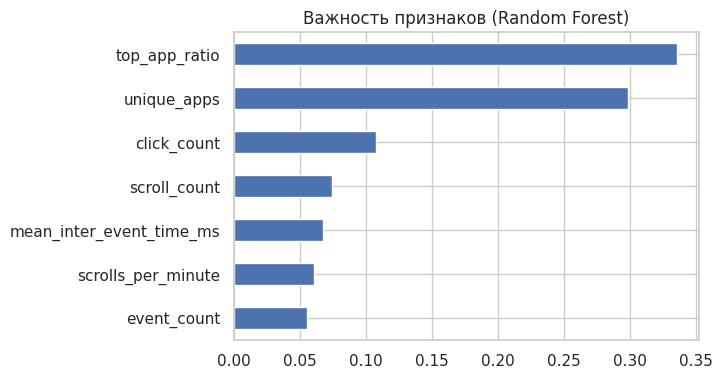

In [125]:
import pandas as pd

fi = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values()

plt.figure(figsize=(6,4))
fi.plot(kind="barh")
plt.title("Важность признаков (Random Forest)")
plt.show()


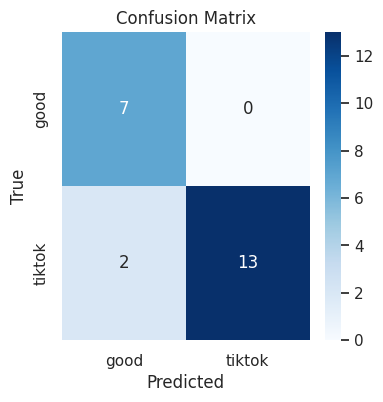

In [126]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_enc, y_pred, labels=[0,1])

plt.figure(figsize=(4,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


### Попытка обучить CatBoost

In [109]:
!pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 5.9 MB/s eta 0:00:00


In [127]:
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report

cb = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function='Logloss',
    eval_metric='F1',
    random_seed=42,
    verbose=False
)

cb.fit(
    X_train_res,
    y_train_res,
    eval_set=(X_test, y_test_enc)
)

y_pred_cb = cb.predict(X_test)

print(classification_report(
    y_test_enc,
    y_pred_cb,
    target_names=le.classes_
))


              precision    recall  f1-score   support

        good       0.88      1.00      0.93         7
      tiktok       1.00      0.93      0.97        15

    accuracy                           0.95        22
   macro avg       0.94      0.97      0.95        22
weighted avg       0.96      0.95      0.96        22



Результаты лучше, чем у случайного леса. Полезная деятельность распознается лучше, на тиктоках меньше ошибок => общая точность тоже повыше




### Попытка обучить XBoost

In [112]:
!pip install xgboost


In [129]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train_res, y_train_res)

y_pred_xgb = xgb.predict(X_test)

print("=== XGBoost ===")
print(classification_report(
    y_test_enc,
    y_pred_xgb,
    target_names=le.classes_
))


=== XGBoost ===
              precision    recall  f1-score   support

        good       0.78      1.00      0.88         7
      tiktok       1.00      0.87      0.93        15

    accuracy                           0.91        22
   macro avg       0.89      0.93      0.90        22
weighted avg       0.93      0.91      0.91        22



Результаты лучше совпадают со случайным лесом. Так даже неинтересно


## Выводы
Все методы, определенные в рамках второго НИРа хорошо подходят для решения задачи классификации типа деятельности по действиям пользователя

Нужно смотреть больше коротких видео и чаще пользоваться телефоном в целом. Собрать ещё побольше и поаккуратнее датасет и попробовать дообучить модели

Остаётся всего-то перенести это дело в полноценное серверное приложение, прикрутить апишку и наладить обработку файлов в промышленном масштабе.